In [3]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.datasets import load_iris

# Load dataset
# data = pd.read_csv("iris.csv") # Original line causing FileNotFoundError
iris = load_iris()
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['target'] = iris.target

# Display first rows
print(data.head())

# Features and target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------- Linear Kernel ----------
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

print("Linear Kernel Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Confusion Matrix (Linear):")
print(confusion_matrix(y_test, y_pred_linear))


# ---------- RBF Kernel ----------
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

print("\nRBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Confusion Matrix (RBF):")
print(confusion_matrix(y_test, y_pred_rbf))

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
Linear Kernel Accuracy: 1.0
Confusion Matrix (Linear):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

RBF Kernel Accuracy: 1.0
Confusion Matrix (RBF):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Saving letter-recognition.xlsx to letter-recognition.xlsx
First 5 rows of dataset:
  letter  xbox  ybox  width  height  onpix  xbar  ybar  x2bar  y2bar  xybar  \
0      T     2     8      3       5      1     8    13      0      6      6   
1      I     5    12      3       7      2    10     5      5      4     13   
2      D     4    11      6       8      6    10     6      2      6     10   
3      N     7    11      6       6      3     5     9      4      6      4   
4      G     2     1      3       1      1     8     6      6      6      6   

   x2ybar  xy2bar  xedge  xedgey  yedge  yedgex  
0      10       8      0       8      0       8  
1       3       9      2       8      4      10  
2       3       7      3       7      3       9  
3       4      10      6      10      2       8  
4       5       9      1       7      5      10  

Accuracy Score:
0.8545

Confusion Matrix:
[[140   1   0   0   0   0   2   0   0   2   0   0   0   0   0   0   0   1
    1   0   0   1   0   0

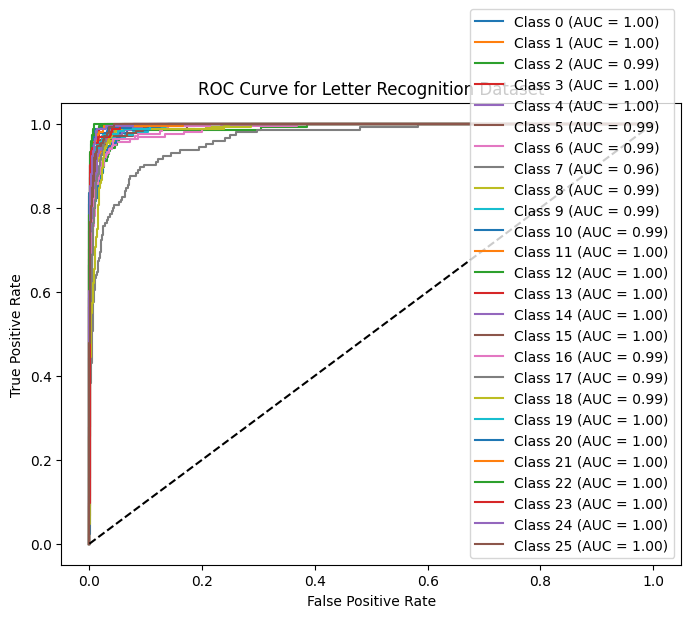


AUC Scores for each class:
{0: np.float64(0.9991582418233562), 1: np.float64(0.9955283040345502), 2: np.float64(0.989819190485818), 3: np.float64(0.9968015421969636), 4: np.float64(0.9968242241127401), 5: np.float64(0.993739822353812), 6: np.float64(0.9873795572916666), 7: np.float64(0.9637019507837714), 8: np.float64(0.9929569705198654), 9: np.float64(0.994813514837077), 10: np.float64(0.9915861657722123), 11: np.float64(0.9963270271404002), 12: np.float64(0.9990586787951089), 13: np.float64(0.9988403283556924), 14: np.float64(0.9954899593005054), 15: np.float64(0.9952225667639876), 16: np.float64(0.991147689348945), 17: np.float64(0.9937093098958334), 18: np.float64(0.9892708614925492), 19: np.float64(0.9966902823812699), 20: np.float64(0.9979270190447966), 21: np.float64(0.9977974947120104), 22: np.float64(0.9995263955544329), 23: np.float64(0.9976075666403279), 24: np.float64(0.9982757977930212), 25: np.float64(0.9968799943593118)}


In [6]:
# Step 1: Upload dataset
from google.colab import files
uploaded = files.upload()

# Step 2: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc

# Step 3: Load dataset
data = pd.read_excel("letter-recognition.xlsx")

# Display dataset
print("First 5 rows of dataset:")
print(data.head())

# Step 4: Separate features and target
X = data.iloc[:,1:]   # Features
y = data.iloc[:,0]    # Target (letter class)

# Step 5: Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Step 6: Build SVM classifier
svm_model = SVC(kernel='linear', probability=True)

# Step 7: Train model
svm_model.fit(X_train, y_train)

# Step 8: Predict test data
y_pred = svm_model.predict(X_test)

# Step 9: Accuracy score
print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

# Step 10: Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Step 11: Convert labels to binary for ROC
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

# Step 12: Predict probabilities
y_score = svm_model.predict_proba(X_test)

# Step 13: Calculate ROC and AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(y_test_bin.shape[1]):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Step 14: Plot ROC Curve
plt.figure(figsize=(8,6))

for i in range(len(roc_auc)):
    plt.plot(fpr[i], tpr[i], label="Class %d (AUC = %0.2f)" % (i, roc_auc[i]))

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Letter Recognition Dataset")
plt.legend(loc="lower right")
plt.show()

# Step 15: Display AUC Scores
print("\nAUC Scores for each class:")
print(roc_auc)